In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import os

In [ ]:
# settings
work_directory = r'C:\Users\...\Code'
os.chdir(work_directory)
# setting: font
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)  # pass in the font dict as kwargs

### Data preprocess

In [ ]:
# loading data

data_directory = '.../basins_5245.csv'
original_data = pd.read_table(data_directory, sep=',', header=0, index_col='OBSID1')
columns_of_interest = ['EBE_MMKYR', 'EBE_ERR', 'GLA_PCNT', 'MATERIAL', 'AREA', 'SLP_deg', 'ELEV_AVE', 'QTZ_PCNT',
                       'SLP_AVE','rock_major', 'rock_count', 'MAP', 'MAT', 'AI', 'NDVI_STS']

data0 = original_data[columns_of_interest].copy()
data0["NDVI"] = data0["NDVI_STS"]

# exclude nodata
Nodata = data0[['MAP', 'NDVI']].isin([-9999]).any(axis=1)
data0 = data0[~Nodata]

# restrict sample materials to "sand" only
data0 = data0[data0['MATERIAL'].isin(['Sa', 'Sed'])]

# depending on the resolution of raster data is about 1 km
data0 = data0[data0['AREA'] > 10]
data0 = data0[data0['AREA'] < 1000]

# denudation, precipitation, and area
data0 = data0[data0['EBE_MMKYR'] >= data0['EBE_MMKYR'].quantile(0.05)]
data0 = data0[data0['EBE_MMKYR'] <= data0['EBE_MMKYR'].quantile(0.95)]

# MAP
data0 = data0[data0['MAP'] <= data0['MAP'].quantile(0.90)]

data0
# data0['NDVI'].describe()
# data0['MAP'].describe()
data1 = data0
# data1

Rows with slope > 10°: 1893
Rows with slope > 15°: 1457
Rows with slope > 20°: 996
Rows with slope > 25°: 625


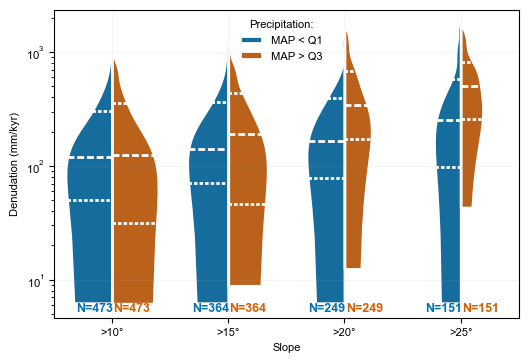

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

slope_thresholds = [10, 15, 20, 25]
slope_labels = [">10°", ">15°", ">20°", ">25°"]

all_list = []

for thr, label in zip(slope_thresholds, slope_labels):
    df_sub = data1[data1['SLP_deg'] > thr].copy()
    print(f"Rows with slope > {thr}°: {len(df_sub)}")

    if len(df_sub) < 10:
        print(f"Slope > {thr}°: total sample size < 10, skipping.")
        continue

    q1 = df_sub['MAP'].quantile(0.25)
    q3 = df_sub['MAP'].quantile(0.75)

    low = df_sub[df_sub['MAP'] < q1].copy()
    high = df_sub[df_sub['MAP'] > q3].copy()

    # More reasonable: check whether the extreme groups also have sufficient samples
    if len(low) < 5 or len(high) < 5:
        print(f"Slope > {thr}°: insufficient samples in Q1/Q3 tails, skipping. low={len(low)}, high={len(high)}")
        continue

    n = min(len(low), len(high))
    low = low.sample(n, random_state=0)
    high = high.sample(n, random_state=0)

    low['Group'] = 'MAP < Q1'
    high['Group'] = 'MAP > Q3'
    low['Slope_group'] = label
    high['Slope_group'] = label

    all_list.extend([low, high])

# Merge datasets
df_plot = pd.concat(all_list, ignore_index=True)

plt.figure(figsize=(6,4))

palette = {"MAP < Q1": "#0072B2",
           "MAP > Q3": "#D55E00"}

ax = sns.violinplot(
    data=df_plot,
    x='Slope_group',
    y='EBE_MMKYR',
    hue='Group',
    palette=palette,
    cut=0,
    split=True,
    inner="quart",
    linewidth=2,
    edgecolor="white"
)

plt.yscale('log')
plt.xlabel("Slope")
plt.ylabel("Denudation (mm/kyr)")
# plt.title("Half-Violin | Slope thresholds vs MAP quantiles")
plt.grid(alpha=0.12)

counts = df_plot.groupby(['Slope_group', 'Group']).size()
for i, slope in enumerate(df_plot['Slope_group'].unique()):
    n_low = counts.get((slope, 'MAP < Q1'), 0)
    n_high = counts.get((slope, 'MAP > Q3'), 0)

    y_min = df_plot['EBE_MMKYR'].min()
    ax.text(i - 0.15, y_min*0.8, f"N={n_low}",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=palette['MAP < Q1'])
    ax.text(i + 0.17, y_min*0.8, f"N={n_high}",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=palette['MAP > Q3'])

plt.legend(title="Precipitation:", frameon=False, bbox_to_anchor=(0.6, 1))
# plt.tight_layout()
# plt.show()
# plt.savefig("Results/260309/Figure 7.svg", dpi=100, bbox_inches='tight')